<table align="center">
  <td align="center"><a target="_blank" href="https://colab.research.google.com/github/sherifmost/DeepLearning/blob/master/Labs/lab1/lab1_part2.ipynb">
        <img src="http://introtodeeplearning.com/images/colab/colab.png?v2.0"  style="padding-bottom:5px;" />Run in Google Colab</a></td>
</table>

# Copyright Information

**Parts of this assignment are based on Kaggle kernels.**

# Assignment 1 - Part2: Logistic Regression

![Logistic Regression](https://raw.githubusercontent.com/KhaledElTahan/AUC-DeepLearning/master/Labs/lab1/logistic_regression.png)

## 1.2.1 Problem Statement

Here, we are trying to increase the people's attention regarding the heart diseases. Like any disease, it is always better to know if you are sick early so you can get the treatment you need before it is too late. Therefore, we use a dataset that gathered some information about two groups: a group with a heart disease and the other group has no disease.
The gathered information includes age, chest pain type, fasting blood sugar, etc.

Your goal is to train a logistic regression model to predict if a person has a heart disease or not depending on the given information.

## 1.2.2 Problem Details

Let's dive into the code, explain it and show you the parts you need to fill!

### 1.2.2.1 Import Needed packages

**Pay close attention to the packages I imported for you**, they will help in the TODOs

In [239]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew # Added skew for data preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, RMSprop
from tensorflow.keras.initializers import RandomNormal, RandomUniform
from tensorflow.keras.losses import BinaryCrossentropy, CategoricalHinge, BinaryFocalCrossentropy
from tensorflow.keras import regularizers
from IPython.display import display #Added display import to print multiple in the same cell
from sklearn.preprocessing import StandardScaler #Added StandardScaler for data preprocessing

### 1.2.2.2 Work on the dataset

This dataset contains 13 features that demonstrate the health state of a person and our target (0 if this person does not have a heart disease and 1 if he has a heart disease.)

We first load the dataset.

In [240]:
dataset = pd.read_csv("https://raw.githubusercontent.com/KhaledElTahan/DeepLearning/master/Labs/lab1/lab1_heart.csv")

A sneak peak on the dataset and how it looks like.

In [241]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Define input and output.

In [242]:
X = dataset.iloc[:, 0:13].values
y = dataset.iloc[:, 13].values
display(X)
display(y)

array([[63.,  1.,  3., ...,  0.,  0.,  1.],
       [37.,  1.,  2., ...,  0.,  0.,  2.],
       [41.,  0.,  1., ...,  2.,  0.,  2.],
       ...,
       [68.,  1.,  0., ...,  1.,  2.,  3.],
       [57.,  1.,  0., ...,  1.,  1.,  3.],
       [57.,  0.,  1., ...,  1.,  1.,  2.]])

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**TODO: Preprocess your data**

1.   Do you need to scale the data? Which type of scaling is better?
2.   Try adding non-linearity by including artificial features (**check the FAQs document**).

![The effect of the boundary with artificial features](https://raw.githubusercontent.com/KhaledElTahan/AUC-DeepLearning/master/Labs/lab1/artificial_features_boundaries.png)

You might have a look on part1 preprocessing and take hints from there.

**Try different types of data preprocessing and include their effect on the accuracy in your report.**


**Make sure to add the following to the report:**


*   Include the default case that no data preprocessing is done (2.1 in the report)
*   Try out two different data preprocessing techniques and include them (2.2, 2.3 in the report)
*   Include the default case that no artificial features are added (2.4 in the report)
*   Try out including artificial features (2.5 in the report)



In [243]:
# TODO: Data Pre-Processing

#2.1 Default: None

#2.2 Using StandardScaler and skewed columns code from part 1
#Make a pandas df for preprocessing
# X = pd.DataFrame(X)

# numeric_feats = X.dtypes[X.dtypes != "object"].index

# skewed_feats = X[numeric_feats].apply(lambda x: skew(x.dropna())) #compute skewnessc
# skewed_feats = skewed_feats[skewed_feats > 0.75] # Get Skewed Columns
# skewed_feats = skewed_feats.index # Get Skewed Columns indices

# # Log scale skewed columns
# # Normalize the skewed distribution for better regression
# X[skewed_feats] = np.log1p(X[skewed_feats])

# # Create Dummy variables for the categorical features
# X = pd.get_dummies(X)

# # Replace the numeric missing values (NaN's) with the mean of their respective columns
# X = X.fillna(X.mean())

# #Scale X
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# #Make a pandas df copy for easier handleing and easy viewing
# X_pandas_df = pd.DataFrame(X)
# display(X_pandas_df.head())

# display(type(X))
# display(type(X_pandas_df))

#2.3 Using MinMaxScaler and no normalization of skewed
#Make a pandas df for preprocessing
# X = pd.DataFrame(X)

# # Create Dummy variables for the categorical features
# X = pd.get_dummies(X)

# # Replace the numeric missing values (NaN's) with the mean of their respective columns
# X = X.fillna(X.mean())

# #Scale X
# scaler = MinMaxScaler()
# X = scaler.fit_transform(X)

# #Make a pandas df copy for easier handleing and easy viewing
# X_pandas_df = pd.DataFrame(X)
# display(X_pandas_df.head())

# display(type(X))
# display(type(X_pandas_df))

#2.5 I will add up to X^3
# X_powers = []
# for i in range(2,4):
#   X_powers.append(X ** i)

# print(X_powers)

# for x in X_powers:
#   X = np.concatenate((X, x), axis=1)

Split dataset into, training, validation and testing splits.

In [244]:
# Get Training Data
train_X, temporary_X, train_y, temporary_y = train_test_split(X, y, train_size=0.75, random_state=0)

# Get Validation & Testing Data
val_X, test_X, val_y, test_y = train_test_split(temporary_X, temporary_y, train_size=0.5, random_state=0)


#Make a pandas df copy for easy viewing
train_X_df = pd.DataFrame(train_X)
display(train_X_df.head())

val_X_df = pd.DataFrame(val_X)
display(val_X_df.head())

test_X_df = pd.DataFrame(test_X)
display(test_X_df.head())

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,58.0,1.0,2.0,132.0,224.0,0.0,0.0,173.0,0.0,3.2,2.0,2.0,3.0
1,52.0,1.0,0.0,112.0,230.0,0.0,1.0,160.0,0.0,0.0,2.0,1.0,2.0
2,54.0,1.0,2.0,150.0,232.0,0.0,0.0,165.0,0.0,1.6,2.0,0.0,3.0
3,59.0,1.0,3.0,178.0,270.0,0.0,0.0,145.0,0.0,4.2,0.0,0.0,3.0
4,67.0,1.0,0.0,120.0,229.0,0.0,0.0,129.0,1.0,2.6,1.0,2.0,3.0


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,41.0,0.0,1.0,126.0,306.0,0.0,1.0,163.0,0.0,0.0,2.0,0.0,2.0
1,55.0,1.0,0.0,160.0,289.0,0.0,0.0,145.0,1.0,0.8,1.0,1.0,3.0
2,50.0,0.0,2.0,120.0,219.0,0.0,1.0,158.0,0.0,1.6,1.0,0.0,2.0
3,52.0,1.0,2.0,138.0,223.0,0.0,1.0,169.0,0.0,0.0,2.0,4.0,2.0
4,42.0,1.0,2.0,120.0,240.0,1.0,1.0,194.0,0.0,0.8,0.0,0.0,3.0


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,41.0,0.0,2.0,112.0,268.0,0.0,0.0,172.0,1.0,0.0,2.0,0.0,2.0
1,57.0,0.0,1.0,130.0,236.0,0.0,0.0,174.0,0.0,0.0,1.0,1.0,2.0
2,62.0,1.0,1.0,120.0,281.0,0.0,0.0,103.0,0.0,1.4,1.0,1.0,3.0
3,51.0,1.0,2.0,110.0,175.0,0.0,1.0,123.0,0.0,0.6,2.0,0.0,2.0
4,39.0,0.0,2.0,138.0,220.0,0.0,1.0,152.0,0.0,0.0,1.0,0.0,2.0


### 1.2.2.3 Define your model here (TODO)

Logistic Regression as a model is exactly like the Linear Regression except for the activation function.

Use this fact to define your model similar to part1 except for the actication function.

![Logistic Regression using Simple Perceptron](https://raw.githubusercontent.com/KhaledElTahan/AUC-DeepLearning/master/Labs/lab1/perceptron_activation.png)

**TODO**:
1. Try different [activation functions](https://www.tensorflow.org/api_docs/python/tf/keras/activations) and include in the report their effect on the accuracy and the training plot.
2. Try different [regularizers](https://www.tensorflow.org/api_docs/python/tf/keras/regularizers) and include in the report their effect on the accuracy and the training plot.


**Make sure to add the following to the report:**


*   Include the default case that sigmoid activation is used (2.6 in the report)
*   Try out another two activation functions and include them (2.7, 2.8 in the report)
*   Include the default case that no regularizer is added (2.9 in the report)
*   Try out two different regularizers and include them (2.10, 2.11 in the report)

In [245]:

# TODO: Define the Model using Tensorflow.Keras

#2.6: Default: Sigmoid

activation = 'sigmoid'
regularizer = regularizers.l2(0.01)

model = Sequential([
    Dense(1, activation=activation, input_shape=(train_X.shape[1],) )
])

# #2.7: Softmax

# activation = 'softmax'
# regularizer = regularizers.l2(0.01)

# model = Sequential([
#     Dense(1, activation=activation, input_shape=(train_X.shape[1],) )
# ])

# #2.8: Hard Sigmoid

# activation = 'hard_sigmoid'
# regularizer = regularizers.l2(0.01)

# model = Sequential([
#     Dense(1, activation=activation, input_shape=(train_X.shape[1],) )
# ])

# #2.10: l2 regularizer at 0.01

# activation = 'sigmoid'
# regularizer = regularizers.l2(0.01)

# model = Sequential([
#     Dense(1, activation=activation, kernel_regularizer=regularizer, input_shape=(train_X.shape[1],) )
# ])

#2.11: l1 regularizer at 0.01

# activation = 'sigmoid'
# regularizer = regularizers.l1(0.01)

# model = Sequential([
#     Dense(1, activation=activation, kernel_regularizer=regularizer, input_shape=(train_X.shape[1],) )
# ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 1.2.2.4 Compile your model and print a summary

**TODO**
1. Try different [losses](https://www.tensorflow.org/api_docs/python/tf/keras/losses) functions and include in the report their effect on the accuracy. Make sure that those losses functions are meant only for classification! Don't use losses functions that are meant for prediction!
2. Try different [optimizers](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers) and include in the report their effect on the accuracy and the training plot.

**Make sure to add the following to the report:**


*   Include the default case that Binary Crossentropy loss is used (2.12 in the report)
*   Try out another two losses and include them (2.13, 2.14 in the report)
*   Include the default case that adam optimizer is used (2.15 in the report)
*   Try out another optimizer and include it (2.16 in the report)

In [246]:
## TODO Try Different losses & optimizers here

#2.12 Default: BCE
#2.15 Default: Adam
# model.compile(loss=BinaryCrossentropy(), metrics=['accuracy'], optimizer=Adam())

#2.13 CategoricalHinge
# model.compile(loss=CategoricalHinge(), metrics=['accuracy'], optimizer=Adam())

#2.14 BinaryFocalCrossentropy
# model.compile(loss=BinaryFocalCrossentropy(), metrics=['accuracy'], optimizer=Adam())

#2.16 SGD
model.compile(loss=BinaryCrossentropy(), metrics=['accuracy'], optimizer=SGD())
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

### 1.2.2.5 Train your model

In [247]:
hist = model.fit(train_X, train_y, verbose=1, validation_data=(val_X, val_y), batch_size=16, epochs=500)

Epoch 1/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5153 - loss: 122.2869 - val_accuracy: 0.5263 - val_loss: 92.8200
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4390 - loss: 167.5840 - val_accuracy: 0.5263 - val_loss: 151.6920
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5683 - loss: 97.6433 - val_accuracy: 0.4737 - val_loss: 262.3370
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4994 - loss: 150.5639 - val_accuracy: 0.4737 - val_loss: 129.5866
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4903 - loss: 118.1544 - val_accuracy: 0.5263 - val_loss: 353.6449
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5843 - loss: 132.9859 - val_accuracy: 0.5263 - val_loss: 145.3384
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5320 - loss: 115.3789 - val_accuracy: 0.4737 - val_loss: 166.5121
Epoch 8/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5387 - loss: 104.56

**The following cell generates the accuracy needed for the report**

Evaluate your testing split, to get the accuracy and the loss score.

In [248]:
score, accuracy = model.evaluate(test_X, test_y, batch_size=16, verbose=0)
print("Test fraction correct (NN-Loss) = {:.2f}".format(score))
print("Test fraction correct (NN-Accuracy) = {:.2f}".format(accuracy))

Test fraction correct (NN-Loss) = 187.55
Test fraction correct (NN-Accuracy) = 0.39


### 1.2.2.6 Visualize Accuracy

**The following cell generates the plots needed for the report**

Plot the training and validation accuracy. Try to interpret those plots.


**TODO: for each experiment you make, include the plot and accuracy in the report and indicate whether there exist any type of *overfitting or underfitting*.**

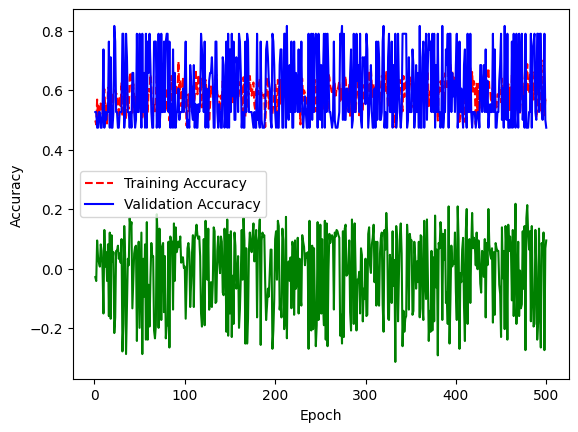

0.5682819485664368
0.4736842215061188
Dif %: 9.4597727060318


In [251]:
# Get training and test loss histories
training_loss = hist.history['accuracy']
val_loss = hist.history['val_accuracy']

acc_gap = [tr - vl for tr, vl in zip(training_loss, val_loss)] #Added this to see the variance trend

# Create count of the number of epochs
epoch_count = range(1, len(training_loss) + 1)

# Visualize loss history
plt.figure()
plt.plot(epoch_count, training_loss, 'r--')
plt.plot(epoch_count, val_loss, 'b-')
plt.plot(epoch_count, acc_gap, 'g')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

print(training_loss[-1])
print(val_loss[-1])
print(f"Dif %: {(training_loss[-1] - val_loss[-1])*100}")

## 1.2.3 Conclusion

That's it! Congratulations on training a logistic regression model.

Make sure you deliver all the requirements for the submission.